In [5]:
import uproot
from pathlib import Path

path = Path("/home/joshin/workspace-gate/store/hdfs-joshin/rpc/tnp-merged-year/Run2023.root")
f = uproot.open(path)
print(f.keys())

OSError: [Errno 5] Input/output error

In [2]:
import time
import numpy as np
import uproot
import mplhep as mh
import matplotlib.pyplot as plt

from pathlib import Path
from tqdm.auto import tqdm


RUN_CONFIG = {
    "2022": {
        "lumi": r"34.7\ fb^{-1}",
        "edgecolor": "firebrick",
        "hatch": "\\\\",
        "alpha": 0.9,
    },
    "2023": {
        "lumi": r"27.9\ fb^{-1}",
        "edgecolor": "mediumblue",
        "hatch": "//",
        "alpha": 0.9,
    },
    "2024": {
        "lumi": r"52.4\ fb^{-1}",
        "edgecolor": "darkgreen",
        "hatch": "oo",
        "alpha": 0.9,
    },
    "2025": {
        "lumi": r"xx.x\ fb^{-1}",
        "edgecolor": "darkorange",
        "hatch": "--",
        "alpha": 0.9,
    },
}

TREE_PATH = "muon_tree"
MASS_BRANCH = "dimuon_mass"
MASS_BINS = 80
MASS_XMIN = 70.0
MASS_XMAX = 110.0
BIN_EDGES = np.linspace(MASS_XMIN, MASS_XMAX, MASS_BINS + 1)


def build_mass_hist_counts(
    root_path: Path,
    tree_path: str = TREE_PATH,
    branch_name: str = MASS_BRANCH,
    step_size: str = "200 MB",
    show_progress: bool = True,
) -> tuple[np.ndarray, np.ndarray]:
    counts = np.zeros(MASS_BINS, dtype=np.int64)

    with uproot.open(root_path) as f:
        tree = f[tree_path]
        total_entries = tree.num_entries

    t0 = time.perf_counter()

    progress = tqdm(
        total=total_entries,
        desc=f"{root_path.stem}",
        unit="entries",
        disable=not show_progress,
    )

    try:
        for arrays in uproot.iterate(
            f"{root_path}:{tree_path}",
            expressions=[branch_name],
            library="np",
            step_size=step_size,
        ):
            values = arrays[branch_name]
            batch_counts, _ = np.histogram(values, bins=BIN_EDGES)
            counts += batch_counts
            progress.update(len(values))
    finally:
        progress.close()

    dt = time.perf_counter() - t0
    print(f"[{root_path.name}] done in {dt:.1f} s")

    return counts, BIN_EDGES


def plot_step_hist(
    ax: plt.Axes,
    counts: np.ndarray,
    edges: np.ndarray,
    *,
    label: str,
    edgecolor: str,
    hatch: str,
    alpha: float,
) -> None:
    widths = np.diff(edges)
    ax.bar(
        edges[:-1],
        counts,
        width=widths,
        align="edge",
        fill=False,
        edgecolor=edgecolor,
        linewidth=3,
        hatch=hatch,
        alpha=alpha,
        label=label,
    )


def hist_tnp_mass(
    input_paths: dict[str, Path],
    output_path: Path,
    step_size: str = "200 MB",
    show_progress: bool = True,
) -> None:
    mh.style.use(mh.styles.CMS)

    fig, ax = plt.subplots(figsize=(12, 8))
    mh.cms.label(
        ax=ax,
        llabel="Work in Progress",
        year="Run 3",
        com=13.6,
        loc=0,
        fontsize=24,
    )

    ax.set_xlabel(r"$\mu^{+}\mu^{-}$ (Tag-Probe) invariant mass [$\mathit{GeV}$]", fontsize=22)
    ax.set_ylabel(r"Events / 0.5 $\mathit{GeV}$", fontsize=22)
    ax.set_xlim(MASS_XMIN, MASS_XMAX)

    ax.ticklabel_format(style="sci", axis="y", scilimits=(0, 0), useMathText=True)
    ax.yaxis.offsetText.set_visible(False)
    ax.annotate(
        r"$x10^{6}$",
        (-0.06, 1.0),
        xycoords="axes fraction",
        fontsize=18,
        horizontalalignment="left",
    )

    for run_year, root_path in input_paths.items():
        if run_year not in RUN_CONFIG:
            raise ValueError(f"Run year '{run_year}' is not configured in RUN_CONFIG.")

        cfg = RUN_CONFIG[run_year]

        counts, edges = build_mass_hist_counts(
            root_path=root_path,
            step_size=step_size,
            show_progress=show_progress,
        )

        plot_step_hist(
            ax,
            counts,
            edges,
            label=rf"${run_year}\ ({cfg['lumi']})$",
            edgecolor=cfg["edgecolor"],
            hatch=cfg["hatch"],
            alpha=cfg["alpha"],
        )

    ax.legend(fontsize=24, handleheight=1.2)

    output_path = Path(output_path)
    output_path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(output_path, dpi=200, bbox_inches="tight")
    plt.close(fig)

/home/joshin/micromamba/envs/rpc-tnp-nanoaod-py312/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


OSError: [Errno 5] Input/output error

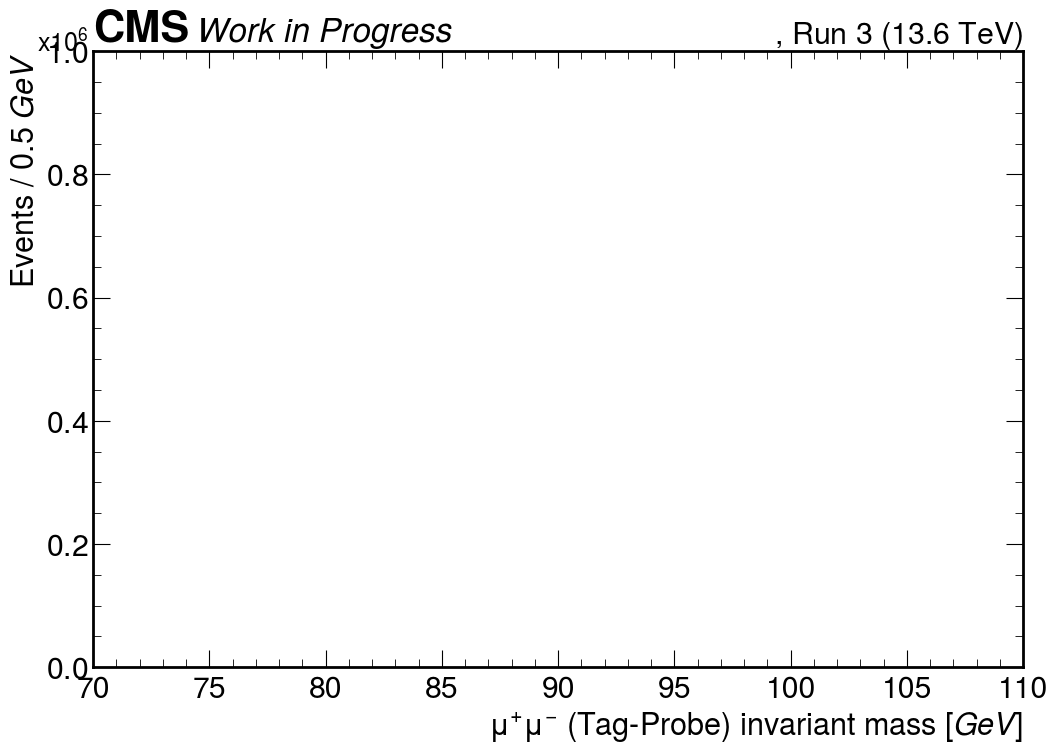

In [3]:
input_paths = {
    "2022": Path("/home/joshin/workspace-gate/store/hdfs-joshin/rpc/tnp-merged-year/Run2022.root"),
    "2023": Path("/home/joshin/workspace-gate/store/hdfs-joshin/rpc/tnp-merged-year/Run2023.root"),
    "2024": Path("/home/joshin/workspace-gate/store/hdfs-joshin/rpc/tnp-merged-year/Run2024.root"),
    "2025": Path("/home/joshin/workspace-gate/store/hdfs-joshin/rpc/tnp-merged-year/Run2025.root"),
}

workspace = Path("/home/joshin/workspace-gate/RPCTnP/CMSSW_16_1_0_pre1/src/RPCDPGAnalysis/NanoAODTnP/plots")

hist_tnp_mass(
    input_paths=input_paths,
    output_path=workspace / "tnp_mass_hist_run3.png",
    step_size="100 MB",
    show_progress=True,
)